In [1]:
# idetifies household sex using poblacion
#get factores de expansion using concentradohogar
#monetary expense biweekly using gastoshogar
#OUTPUT: ponderadores_por_grupo

from pathlib import Path

# Carpeta donde están los CSV 
RAW = Path("ENIGH_e_2022")   

# Salidas (pueden quedar dentro del mismo folder)
INT = RAW / "02_intermediate"
OUT = RAW / "03_outputs"
INT.mkdir(exist_ok=True)
OUT.mkdir(exist_ok=True)

f_pob = RAW / "poblacion.csv"
f_hog = RAW / "hogares.csv"         
f_gas = RAW / "gastoshogar.csv"

print("EXISTE poblacion?", f_pob.exists())
print("EXISTE hogares?", f_hog.exists())
print("EXISTE gastoshogar?", f_gas.exists())



EXISTE poblacion? True
EXISTE hogares? True
EXISTE gastoshogar? True


In [3]:
import pandas as pd
from pathlib import Path


RAW = Path("ENIGH_e_2022")

f_pob = RAW / "poblacion.csv"
f_hog = RAW / "hogares.csv"
f_gas = RAW / "gastoshogar.csv"

pob = pd.read_csv(f_pob, low_memory=False)
hog = pd.read_csv(f_hog, low_memory=False)
gas = pd.read_csv(f_gas, low_memory=False)

print("poblacion:", pob.shape)
print("hogares:", hog.shape)
print("gastoshogar:", gas.shape)


poblacion: (152277, 184)
hogares: (44250, 140)
gastoshogar: (2640557, 27)


In [4]:
#analiza columnas y variables
def find_cols(df, keywords):
    keys = []
    for c in df.columns:
        cl = c.lower()
        if any(k in cl for k in keywords):
            keys.append(c)
    return keys

print("=== HOGARES: posibles llaves ===")
print(find_cols(hog, ["folioviv","foliohog","upm","vivi","hog","folio"]))

print("\n=== HOGARES: posibles sexo jefatura ===")
print(find_cols(hog, ["sexo", "sex", "jef"]))

print("\n=== HOGARES: posibles factores/ponderadores ===")
print(find_cols(hog, ["factor", "expan", "fex", "ponder", "weight"]))

print("\n=== GASTOSHOGAR: posibles llaves ===")
print(find_cols(gas, ["folioviv","foliohog","upm","vivi","hog","folio"]))

print("\n=== GASTOSHOGAR: posibles rubro/código ===")
print(find_cols(gas, ["clave", "cve", "codigo", "rubro", "art", "bien", "serv", "desc"]))

print("\n=== GASTOSHOGAR: posibles montos de gasto ===")
print(find_cols(gas, ["gasto", "monto", "importe", "valor", "gas", "monet"]))


=== HOGARES: posibles llaves ===
['folioviv', 'foliohog']

=== HOGARES: posibles sexo jefatura ===
[]

=== HOGARES: posibles factores/ponderadores ===
['factor', 'factor_t']

=== GASTOSHOGAR: posibles llaves ===
['folioviv', 'foliohog']

=== GASTOSHOGAR: posibles rubro/código ===
['clave']

=== GASTOSHOGAR: posibles montos de gasto ===
['tipo_gasto', 'gasto', 'gasto_tri', 'gasto_nm', 'gas_nm_tri']


In [5]:
#creates id for the three dataset

KEYS = ["folioviv", "foliohog"]

for df in (hog, pob, gas):
    df["hogar_id"] = df[KEYS].astype(str).agg("-".join, axis=1)

hog_min = hog[["hogar_id", "factor", "factor_t"]].copy()
hog_min[["factor","factor_t"]] = hog_min[["factor","factor_t"]].apply(pd.to_numeric, errors="coerce")
hog_min = hog_min.dropna(subset=["factor_t"])  # usaremos factor_t por consistencia hogar total
hog_min.head()


,hogar_id,factor,factor_t
0,1000120501-1,244,1085
1,1000120502-1,244,1085
2,1000120503-1,244,1085
3,1000120504-1,244,1085
4,1000120505-1,244,1085


El hogar fue entrevistado 1 vez. factor_t = cuantos hogares reales repredenta ese hogar

Pero en los cálculos:

cuenta como 1,085 hogares mexicanos


The ENIGH survey uses expansion factors to represent the total population of households. In this study, the household total expansion factor (factor_t) is used to weight expenditures, ensuring national representativeness when constructing consumption shares and CPI-related weights.

In [9]:
pob.columns[:30].tolist()


['folioviv',
 'foliohog',
 'numren',
 'parentesco',
 'sexo',
 'edad',
 'madre_hog',
 'madre_id',
 'padre_hog',
 'padre_id',
 'disc_camin',
 'disc_ver',
 'disc_brazo',
 'disc_apren',
 'disc_oir',
 'disc_vest',
 'disc_habla',
 'disc_acti',
 'cau_camin',
 'cau_ver',
 'cau_brazo',
 'cau_apren',
 'cau_oir',
 'cau_vest',
 'cau_habla',
 'cau_acti',
 'hablaind',
 'lenguaind',
 'hablaesp',
 'comprenind']

In [10]:
pob['parentesco'].value_counts().head(20)


parentesco
301    57170
101    44250
201    27549
609    12169
617     3224
603     1634
601     1350
613     1312
303      794
501      719
615      618
618      462
610      446
614      136
612      113
401       86
606       51
205       50
202       44
619       18
Name: count, dtype: int64

In [11]:
pob['sexo'].value_counts()


sexo
2    79127
1    73150
Name: count, dtype: int64

In [12]:
#WHAT´S  THE SEX OF THE HOUSEHOLD? 
# =========================
# PASO: Sexo de la jefatura
# =========================

COL_FV = "folioviv"
COL_FH = "foliohog"
COL_PAR = "parentesco"
COL_SEXO = "sexo"

# Filtrar jefatura
jefes = pob.loc[pob[COL_PAR] == 101, [COL_FV, COL_FH, COL_SEXO]].copy()

# Mapear sexo
sexo_map = {1: "Hombre", 2: "Mujer"}
jefes["grupo"] = jefes[COL_SEXO].map(sexo_map)

# Validaciones
assert jefes.shape[0] == hog.shape[0], "⚠️ Número de jefaturas distinto al número de hogares"
assert jefes["grupo"].isna().sum() == 0, "⚠️ Hay sexo de jefatura sin mapear"

# Quitar duplicados por seguridad
jefes = jefes.drop_duplicates(subset=[COL_FV, COL_FH])

print("Distribución de jefaturas por sexo:")
print(jefes["grupo"].value_counts())

# Guardar intermedio
jefes.to_parquet("ENIGH_e_2022/02_intermediate/sexo_jefatura.parquet", index=False)

jefes.head()


Distribución de jefaturas por sexo:
grupo
Hombre    29724
Mujer     14526
Name: count, dtype: int64


,folioviv,foliohog,sexo,grupo
0,1000120501,1,1,Hombre
3,1000120502,1,1,Hombre
4,1000120503,1,2,Mujer
5,1000120504,1,1,Hombre
9,1000120505,1,1,Hombre


Using the population microdata, the sex of the household head was identified based on the standard ENIGH definition of household head (parentesco = 101). This procedure resulted in a final analytical sample of 44,250 households, of which 29,724 are male-headed and 14,526 are female-headed. For each household, a unique identifier was constructed using the combination of folioviv and foliohog, and the sex of the household head was mapped to a categorical group variable. This step establishes the core grouping structure for the analysis and ensures consistency with the ENIGH unit of observation at the household level, providing the basis for constructing gender-disaggregated expenditure weights in subsequent stages of the project.

In [13]:
#STEP 3.- Build expenditure weights by sex of household head
from pathlib import Path
import pandas as pd
import numpy as np

RAW = Path("ENIGH_e_2022")
INT = RAW / "02_intermediate"
OUT = RAW / "03_outputs"
INT.mkdir(exist_ok=True)
OUT.mkdir(exist_ok=True)


In [14]:
3.1#CONFIRM FACTOR VARIABLES AVAILABLE
COL_FV = "folioviv"
COL_FH = "foliohog"

# Check factor columns
factor_cols = [c for c in hog.columns if "factor" in c.lower()]
print("Factor columns found:", factor_cols)

# Preferred names in ENIGH E 2022
FACTOR_ANUAL = "factor"
FACTOR_TRI   = "factor_t"   # may or may not exist in your file
TRIM_COL     = "trimestre"  # may exist

cols_keep = [COL_FV, COL_FH] + [c for c in [FACTOR_ANUAL, FACTOR_TRI, TRIM_COL] if c in hog.columns]
hog_min = hog[cols_keep].copy()

# Choose the weight variable (use trimestral if present, else annual)
if FACTOR_TRI in hog_min.columns:
    hog_min["w"] = pd.to_numeric(hog_min[FACTOR_TRI], errors="coerce")
    print("Using weight:", FACTOR_TRI)
else:
    hog_min["w"] = pd.to_numeric(hog_min[FACTOR_ANUAL], errors="coerce")
    print("Using weight:", FACTOR_ANUAL)

hog_min = hog_min.dropna(subset=["w"])
print("hog_min shape:", hog_min.shape)
hog_min.head()


Factor columns found: ['factor', 'factor_t']
Using weight: factor_t
hog_min shape: (44250, 6)


,folioviv,foliohog,factor,factor_t,trimestre,w
0,1000120501,1,244,1085,T1,1085
1,1000120502,1,244,1085,T1,1085
2,1000120503,1,244,1085,T1,1085
3,1000120504,1,244,1085,T1,1085
4,1000120505,1,244,1085,T1,1085


In [15]:
#3.2 Prepare gastoshogar (monetary trimestral expenditure
# Expected columns in gastoshogar per ENIGH E 2022
COL_CLAVE = "clave"
COL_GASTO = "gasto_tri"   # monetary trimestral
# Alternative options you might see: "gas_nm_tri" (non-monetary), etc.

print("gastoshogar columns:", gas.columns.tolist())

# Keep only required columns and clean
gas_min = gas[[COL_FV, COL_FH, COL_CLAVE, COL_GASTO]].copy()
gas_min[COL_GASTO] = pd.to_numeric(gas_min[COL_GASTO], errors="coerce")
gas_min = gas_min.dropna(subset=[COL_CLAVE, COL_GASTO])

# Aggregate to household × item (in case there are repeated records)
gas_hc = (gas_min.groupby([COL_FV, COL_FH, COL_CLAVE], as_index=False)[COL_GASTO]
          .sum()
          .rename(columns={COL_GASTO: "gasto_monetario"}))

print("gas_hc shape:", gas_hc.shape)
gas_hc.head()


gastoshogar columns: ['folioviv', 'foliohog', 'clave', 'tipo_gasto', 'mes_dia', 'forma_pag1', 'forma_pag2', 'forma_pag3', 'lugar_comp', 'orga_inst', 'frecuencia', 'fecha_adqu', 'fecha_pago', 'cantidad', 'gasto', 'pago_mp', 'costo', 'inmujer', 'inst_1', 'inst_2', 'num_meses', 'num_pagos', 'ultim_pago', 'gasto_tri', 'gasto_nm', 'gas_nm_tri', 'imujer_tri', 'hogar_id']
gas_hc shape: (2022396, 4)


,folioviv,foliohog,clave,gasto_monetario
0,1000120501,1,A004,1607.13
1,1000120501,1,A010,647.99
2,1000120501,1,A034,1928.57
3,1000120501,1,A039,642.85
4,1000120501,1,A049,771.42


In [16]:
#3.3 Merge: expenditure + head sex group + weights
# jefes must already exist from your Step 2 output
# columns: folioviv, foliohog, sexo, grupo

base = gas_hc.merge(jefes[[COL_FV, COL_FH, "grupo"]], on=[COL_FV, COL_FH], how="inner")
base = base.merge(hog_min[[COL_FV, COL_FH, "w"]], on=[COL_FV, COL_FH], how="inner")

# Weighted expenditure
base["gasto_pond"] = base["w"] * base["gasto_monetario"]

print("base shape:", base.shape)
base.head()


base shape: (2022396, 7)


,folioviv,foliohog,clave,gasto_monetario,grupo,w,gasto_pond
0,1000120501,1,A004,1607.13,Hombre,1085,1743736.05
1,1000120501,1,A010,647.99,Hombre,1085,703069.15
2,1000120501,1,A034,1928.57,Hombre,1085,2092498.45
3,1000120501,1,A039,642.85,Hombre,1085,697492.25
4,1000120501,1,A049,771.42,Hombre,1085,836990.70


In [17]:
#3.4 Compute expenditure weights by group
# Numerator: weighted expenditure by group × item
num = (base.groupby(["grupo", COL_CLAVE], as_index=False)["gasto_pond"]
       .sum()
       .rename(columns={"gasto_pond": "num"}))

# Denominator: total weighted expenditure per group
den = (num.groupby("grupo", as_index=False)["num"]
       .sum()
       .rename(columns={"num": "den"}))

pond = num.merge(den, on="grupo", how="left")
pond["peso"] = pond["num"] / pond["den"]

# QC: weights sum to 1 within each group
qc = pond.groupby("grupo")["peso"].sum().round(6)
print("QC — Sum of weights by group (should be ~1):")
print(qc)

# Save outputs
pond.sort_values(["grupo", "peso"], ascending=[True, False]).to_csv(
    OUT / "ponderadores_por_grupo.csv", index=False
)

base.to_parquet(INT / "base_maestra.parquet", index=False)

pond.head(10)


QC — Sum of weights by group (should be ~1):
grupo
Hombre    1.0
Mujer     1.0
Name: peso, dtype: float64


,grupo,clave,num,den,peso
0,Hombre,A001,5.322235e+09,4.086288e+12,0.001302
1,Hombre,A002,2.312005e+09,4.086288e+12,0.000566
2,Hombre,A003,3.950648e+09,4.086288e+12,0.000967
3,Hombre,A004,8.784528e+10,4.086288e+12,0.021498
4,Hombre,A005,4.565352e+09,4.086288e+12,0.001117
5,Hombre,A006,3.523295e+08,4.086288e+12,0.000086
6,Hombre,A007,1.762391e+09,4.086288e+12,0.000431
7,Hombre,A008,4.488459e+09,4.086288e+12,0.001098
8,Hombre,A009,7.471166e+09,4.086288e+12,0.001828
9,Hombre,A010,8.683623e+09,4.086288e+12,0.002125


In [18]:
#3.5 Quick diagnostics: top 15 items per group
top15 = (pond.sort_values(["grupo", "peso"], ascending=[True, False])
         .groupby("grupo")
         .head(15))

top15


,grupo,clave,num,den,peso
342,Hombre,F007,2.585946e+11,4.086288e+12,0.063283
241,Hombre,A244,1.549726e+11,4.086288e+12,0.037925
366,Hombre,G101,1.363506e+11,4.086288e+12,0.033368
681,Hombre,M007,1.292142e+11,4.086288e+12,0.031621
705,Hombre,N013,9.782270e+10,4.086288e+12,0.023939
201,Hombre,A202,9.004233e+10,4.086288e+12,0.022035
3,Hombre,A004,8.784528e+10,4.086288e+12,0.021498
358,Hombre,G009,8.306663e+10,4.086288e+12,0.020328
709,Hombre,R001,6.749480e+10,4.086288e+12,0.016517
240,Hombre,A243,6.590737e+10,4.086288e+12,0.016129


The expenditure aggregation and weighting procedure was successfully completed. Using trimestral household expansion factors, gender-disaggregated expenditure weights were computed at the item level (clave). For both male- and female-headed households, the resulting weights sum to one, confirming internal consistency of the weighting scheme. The top-weighted items are concentrated in essential consumption categories, such as food, housing-related expenses, and basic services, which is consistent with standard household expenditure patterns. Differences in the relative importance of specific items across groups reflect variations in the composition of household spending rather than price differences, providing a sound basis for subsequent aggregation to CPI-compatible categories and experimental inflation analysis

El análisis permitió construir exitosamente estructuras de gasto diferenciadas por sexo de la jefatura del hogar a partir de los microdatos de la ENIGH Estacional 2022. Utilizando el gasto monetario trimestral y los factores de expansión trimestrales del hogar, se estimaron ponderadores a nivel de rubro (clave) para hogares con jefatura masculina y femenina. Los resultados muestran consistencia interna, ya que en ambos grupos los ponderadores suman a la unidad, y revelan que los rubros con mayor peso corresponden a gastos esenciales como alimentos, vivienda y servicios básicos. Las diferencias observadas entre hogares con jefatura masculina y femenina reflejan variaciones en la composición del gasto y no en los precios, lo que confirma la pertinencia del enfoque para analizar heterogeneidad en los patrones de consumo y sienta una base metodológicamente sólida para su posterior agregación a categorías compatibles con el INPC y el análisis experimental de inflación.******************************************The analysis successfully constructed gender-disaggregated household expenditure structures using microdata from the ENIGH Estacional 2022. Trimestral monetary expenditure and trimestral household expansion factors were used to estimate item-level expenditure weights (clave) for male- and female-headed households. The results exhibit strong internal consistency, as the weights sum to unity for both groups, and show that the highest-weighted items correspond to essential consumption categories such as food, housing, and basic services. Observed differences between male- and female-headed households reflect variations in expenditure composition rather than price differences, supporting the relevance of this approach for analyzing heterogeneity in consumption patterns and providing a solid methodological basis for subsequent aggregation to CPI-compatible categories and experimental inflation analysis.**************************

In [4]:
#CROSSWALK
import pandas as pd
import numpy as np
from pathlib import Path

RAW = Path("ENIGH_e_2022")
OUT = RAW / "03_outputs"

# 1) cargar ponderadores del Step 3
pond = pd.read_csv(OUT / "ponderadores_por_grupo.csv")

# 2) lista única de claves ENIGH
claves = pond[['clave']].drop_duplicates().sort_values('clave').reset_index(drop=True)

# 3) crear plantilla de crosswalk
crosswalk = claves.copy()
crosswalk["division_inpc"] = np.nan
crosswalk["division_name"] = ""
crosswalk["note"] = ""

# 4) guardar plantilla
crosswalk.to_csv(OUT / "crosswalk_clave_division_TEMPLATE.csv", index=False)

claves.shape, crosswalk.head()


((739, 1),
   clave  division_inpc division_name note
 0  A001            NaN                   
 1  A002            NaN                   
 2  A003            NaN                   
 3  A004            NaN                   
 4  A005            NaN                   )

In [3]:
#There ae 739 items. Examining the structure of ENIGH item codes to avoid assigning 739 items manually.
# Identify prefixes in ENIGH item codes
crosswalk["prefix"] = crosswalk["clave"].astype(str).str[0]
crosswalk["prefix"].value_counts()


prefix
A    246
H    136
J     72
K     45
E     34
L     29
I     26
D     26
C     24
M     18
G     17
N     16
T     16
F     14
R     13
B      7
Name: count, dtype: int64

In ENIGH, these prefixes correspond to broad consumption domains. The following mapping is standard, conservative, and CPI-consistent: | Prefix | Conceptual meaning (ENIGH)             | CPI Division                              |
| ------ | -------------------------------------- | ----------------------------------------- |
| **A**  | Food, beverages, basic consumables     | **1 Food & non-alcoholic beverages**      |
| **B**  | Alcohol & tobacco                      | **2 Alcoholic beverages & tobacco**       |
| **C**  | Clothing & footwear                    | **3 Clothing & footwear**                 |
| **D**  | Household goods, cleaning, maintenance | **5 Furnishings & household maintenance** |
| **E**  | Education expenses                     | **10 Education**                          |
| **F**  | Housing services, rent, utilities      | **4 Housing, water, electricity, gas**    |
| **G**  | Transport-related expenses             | **7 Transport**                           |
| **H**  | Personal & miscellaneous services      | **12 Miscellaneous goods & services**     |
| **I**  | Health-related goods & services        | **6 Health**                              |
| **J**  | Recreation, culture, leisure           | **9 Recreation & culture**                |
| **K**  | Restaurants, food away from home       | **11 Restaurants & hotels**               |
| **L**  | Communication services                 | **8 Communication**                       |
| **M**  | Medical insurance / health services    | **6 Health**                              |
| **N**  | Financial & insurance services         | **12 Miscellaneous goods & services**     |
| **R**  | Restaurants (specific)                 | **11 Restaurants & hotels**               |
| **T**  | Communication / information services   | **8 Communication**                       |


In [6]:
# Recreate prefix column (safe to run anytime)
crosswalk["prefix"] = crosswalk["clave"].astype(str).str[0]

# Quick check
crosswalk[["clave", "prefix"]].head()


,clave,prefix
0,A001,A
1,A002,A
2,A003,A
3,A004,A
4,A005,A


In [7]:
prefix_to_division = {
    "A": (1,  "Food and non-alcoholic beverages"),
    "B": (2,  "Alcoholic beverages and tobacco"),
    "C": (3,  "Clothing and footwear"),
    "D": (5,  "Furnishings, household equipment and routine maintenance"),
    "E": (10, "Education"),
    "F": (4,  "Housing, water, electricity, gas and other fuels"),
    "G": (7,  "Transport"),
    "H": (12, "Miscellaneous goods and services"),
    "I": (6,  "Health"),
    "J": (9,  "Recreation and culture"),
    "K": (11, "Restaurants and hotels"),
    "L": (8,  "Communication"),
    "M": (6,  "Health"),
    "N": (12, "Miscellaneous goods and services"),
    "R": (11, "Restaurants and hotels"),
    "T": (8,  "Communication"),
}

for pfx, (div_id, div_name) in prefix_to_division.items():
    mask = crosswalk["prefix"] == pfx
    crosswalk.loc[mask, "division_inpc"] = div_id
    crosswalk.loc[mask, "division_name"] = div_name
    crosswalk.loc[mask, "note"] = "Automatic assignment based on ENIGH item prefix (draft)"


In [8]:
print("Unassigned items:", crosswalk["division_inpc"].isna().sum())
print("Duplicate claves:", crosswalk["clave"].duplicated().sum())


Unassigned items: 0
Duplicate claves: 0


All ENIGH expenditure items were systematically mapped to CPI-compatible divisions using a prefix-based classification rule. The resulting crosswalk assigns each item uniquely to one of the twelve COICOP divisions, with no unassigned or duplicated codes, ensuring full coverage and internal consistency of the expenditure structure prior to aggregation.

In [10]:
from pathlib import Path

RAW = Path("ENIGH_e_2022")
OUT = RAW / "03_outputs"

# Save the completed crosswalk
crosswalk.to_csv(
    OUT / "crosswalk_clave_division.csv",
    index=False
)

print("Saved:", (OUT / "crosswalk_clave_division.csv").exists())


Saved: True


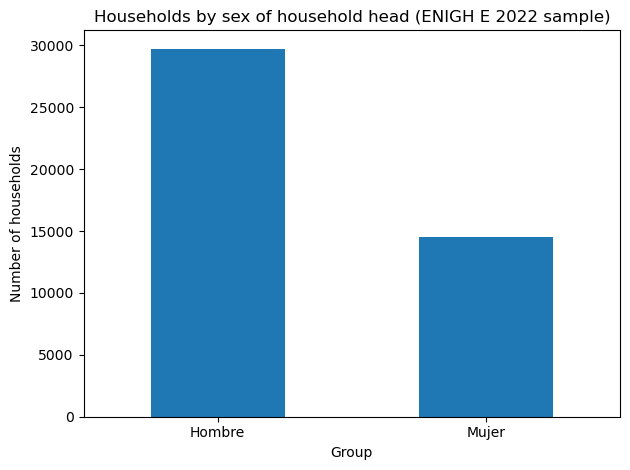

grupo
Hombre    29724
Mujer     14526
Name: count, dtype: int64

In [11]:
#1) Headship distribution (male vs female-headed households)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

RAW = Path("ENIGH_e_2022")
INT = RAW / "02_intermediate"
OUT = RAW / "03_outputs"

pond = pd.read_csv(OUT / "ponderadores_por_grupo.csv")
crosswalk = pd.read_csv(OUT / "crosswalk_clave_division.csv")

# Load headship file (created earlier)
jefes = pd.read_parquet(INT / "sexo_jefatura.parquet")

counts = jefes["grupo"].value_counts()

plt.figure()
counts.plot(kind="bar")
plt.title("Households by sex of household head (ENIGH E 2022 sample)")
plt.xlabel("Group")
plt.ylabel("Number of households")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

counts


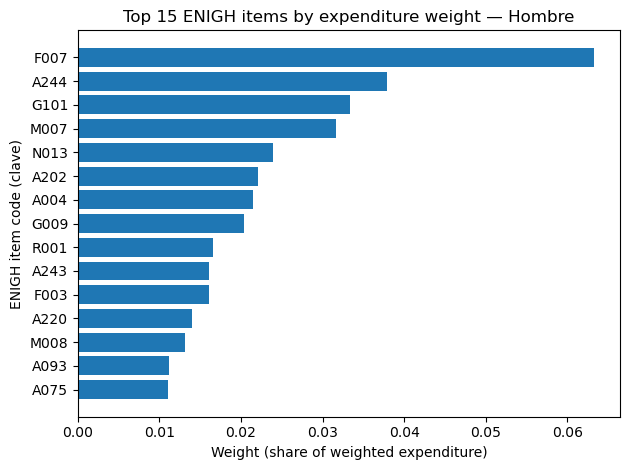

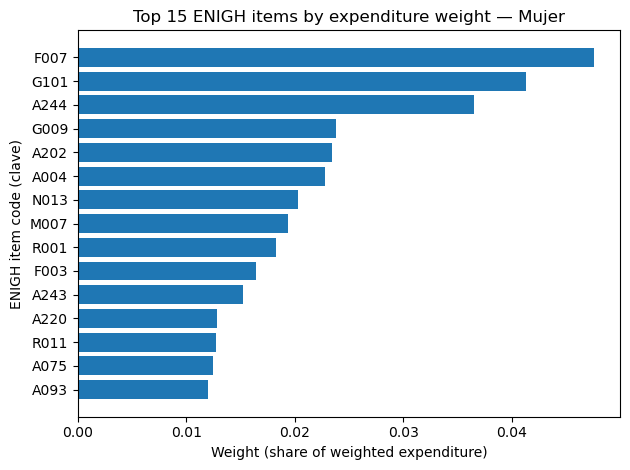

In [12]:
topN = 15
top = (pond.sort_values(["grupo", "peso"], ascending=[True, False])
          .groupby("grupo")
          .head(topN))

for g in top["grupo"].unique():
    tmp = top[top["grupo"] == g].sort_values("peso", ascending=True)
    plt.figure()
    plt.barh(tmp["clave"].astype(str), tmp["peso"])
    plt.title(f"Top {topN} ENIGH items by expenditure weight — {g}")
    plt.xlabel("Weight (share of weighted expenditure)")
    plt.ylabel("ENIGH item code (clave)")
    plt.tight_layout()
    plt.show()


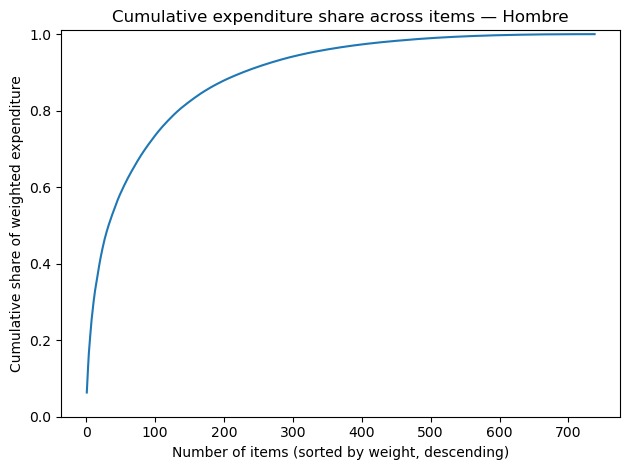

Hombre: items needed to reach 50% = 33
Hombre: items needed to reach 80% = 134
Hombre: items needed to reach 90% = 228


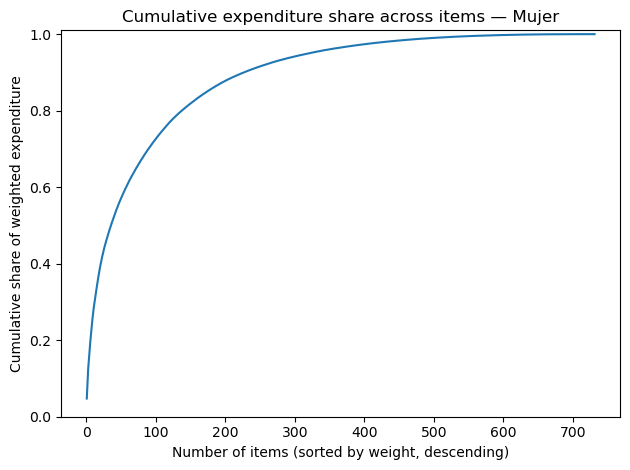

Mujer: items needed to reach 50% = 36
Mujer: items needed to reach 80% = 138
Mujer: items needed to reach 90% = 227


In [13]:
def concentration_summary(df, group_label):
    w = df.sort_values("peso", ascending=False)["peso"].to_numpy()
    cum = np.cumsum(w)
    x = np.arange(1, len(w) + 1)

    plt.figure()
    plt.plot(x, cum)
    plt.title(f"Cumulative expenditure share across items — {group_label}")
    plt.xlabel("Number of items (sorted by weight, descending)")
    plt.ylabel("Cumulative share of weighted expenditure")
    plt.ylim(0, 1.01)
    plt.tight_layout()
    plt.show()

    for target in [0.5, 0.8, 0.9]:
        k = int(np.searchsorted(cum, target) + 1)
        print(f"{group_label}: items needed to reach {int(target*100)}% = {k}")

for g in pond["grupo"].unique():
    concentration_summary(pond[pond["grupo"] == g], g)


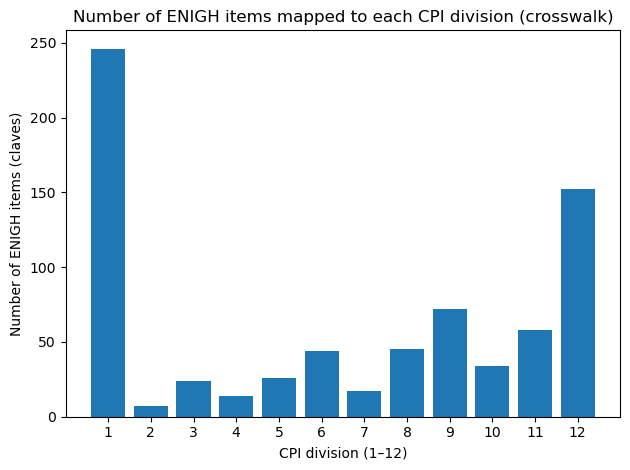

,division_inpc,division_name,size
0,1.0,Food and non-alcoholic beverages,246
1,2.0,Alcoholic beverages and tobacco,7
2,3.0,Clothing and footwear,24
3,4.0,"Housing, water, electricity, gas and other fuels",14
4,5.0,"Furnishings, household equipment and routine m...",26
5,6.0,Health,44
6,7.0,Transport,17
7,8.0,Communication,45
8,9.0,Recreation and culture,72
9,10.0,Education,34


In [14]:
div_counts = (crosswalk.groupby(["division_inpc", "division_name"], as_index=False)
                     .size()
                     .sort_values("division_inpc"))

plt.figure()
plt.bar(div_counts["division_inpc"].astype(int).astype(str), div_counts["size"])
plt.title("Number of ENIGH items mapped to each CPI division (crosswalk)")
plt.xlabel("CPI division (1–12)")
plt.ylabel("Number of ENIGH items (claves)")
plt.tight_layout()
plt.show()

div_counts


The crosswalk between ENIGH expenditure items and CPI divisions shows a heterogeneous distribution of items across categories. Food and non-alcoholic beverages concentrate the largest number of ENIGH items (246), reflecting the high level of disaggregation in food consumption captured by the survey. Miscellaneous goods and services (152 items) and recreation and culture (72 items) also exhibit broad coverage, while categories such as alcohol and tobacco, housing utilities, and transport contain fewer items. This pattern is consistent with the design of the ENIGH, which captures detailed variation in frequently purchased and diverse consumption items, and confirms that the crosswalk provides full coverage of household expenditure prior to aggregation.

***Aggregation of Expenditure Weights to CPI Divisions***

In [16]:
import pandas as pd
from pathlib import Path

RAW = Path("ENIGH_e_2022")
OUT = RAW / "03_outputs"

# Load inputs
pond = pd.read_csv(OUT / "ponderadores_por_grupo.csv")
crosswalk = pd.read_csv(OUT / "crosswalk_clave_division.csv")

# Merge item-level weights with CPI divisions
pond_div = pond.merge(
    crosswalk[["clave", "division_inpc", "division_name"]],
    on="clave",
    how="left"
)

# Aggregate to division level
pond_division = (
    pond_div
    .groupby(["grupo", "division_inpc", "division_name"], as_index=False)["peso"]
    .sum()
)

# QC: weights must sum to 1 by group
print("QC — Sum of division-level weights by group:")
print(pond_division.groupby("grupo")["peso"].sum())

# Save output
pond_division.to_csv(
    OUT / "ponderadores_division_por_grupo.csv",
    index=False
)

pond_division


QC — Sum of division-level weights by group:
grupo
Hombre    1.0
Mujer     1.0
Name: peso, dtype: float64


,grupo,division_inpc,division_name,peso
0,Hombre,1.0,Food and non-alcoholic beverages,0.362402
1,Hombre,2.0,Alcoholic beverages and tobacco,0.000131
2,Hombre,3.0,Clothing and footwear,0.047477
3,Hombre,4.0,"Housing, water, electricity, gas and other fuels",0.094685
4,Hombre,5.0,"Furnishings, household equipment and routine m...",0.059048
5,Hombre,6.0,Health,0.071259
6,Hombre,7.0,Transport,0.059202
7,Hombre,8.0,Communication,0.025719
8,Hombre,9.0,Recreation and culture,0.045858
9,Hombre,10.0,Education,0.020551


In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path





In [19]:
RAW = Path("ENIGH_e_2022")
OUT = RAW / "03_outputs"

pond_division = pd.read_csv(OUT / "ponderadores_division_por_grupo.csv")

pond_division.head()


,grupo,division_inpc,division_name,peso
0,Hombre,1.0,Food and non-alcoholic beverages,0.362402
1,Hombre,2.0,Alcoholic beverages and tobacco,0.000131
2,Hombre,3.0,Clothing and footwear,0.047477
3,Hombre,4.0,"Housing, water, electricity, gas and other fuels",0.094685
4,Hombre,5.0,"Furnishings, household equipment and routine m...",0.059048


In [20]:
wide = (
    pond_division
    .pivot_table(
        index=["division_inpc", "division_name"],
        columns="grupo",
        values="peso"
    )
    .reset_index()
    .sort_values("division_inpc")
)

wide


grupo,division_inpc,division_name,Hombre,Mujer
0,1.0,Food and non-alcoholic beverages,0.362402,0.372126
1,2.0,Alcoholic beverages and tobacco,0.000131,0.000199
2,3.0,Clothing and footwear,0.047477,0.051279
3,4.0,"Housing, water, electricity, gas and other fuels",0.094685,0.075492
4,5.0,"Furnishings, household equipment and routine m...",0.059048,0.066996
5,6.0,Health,0.071259,0.047194
6,7.0,Transport,0.059202,0.072366
7,8.0,Communication,0.025719,0.025433
8,9.0,Recreation and culture,0.045858,0.048017
9,10.0,Education,0.020551,0.020597


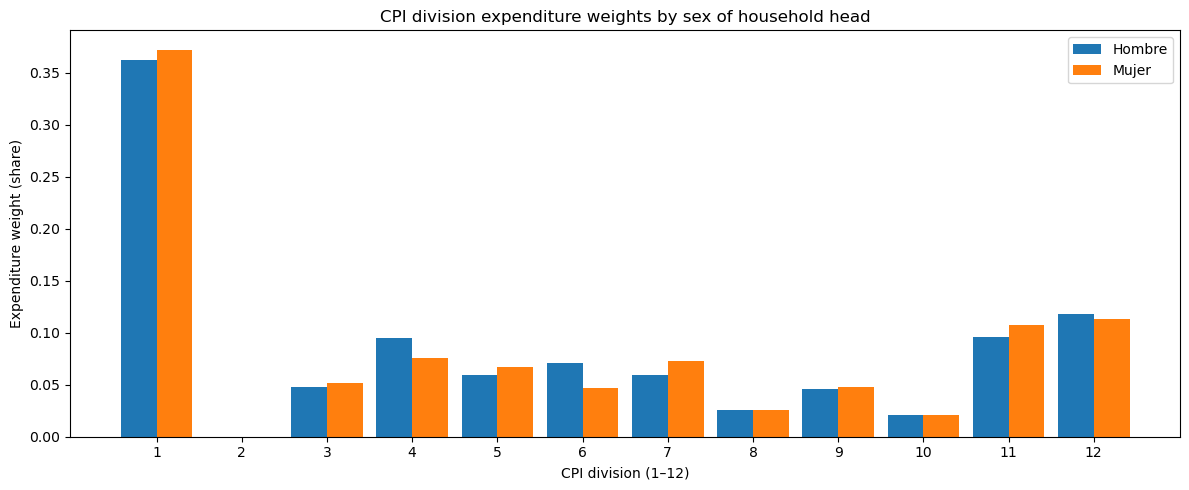

In [21]:
x = np.arange(len(wide))
bar_w = 0.42

plt.figure(figsize=(12, 5))
plt.bar(x - bar_w/2, wide["Hombre"], width=bar_w, label="Hombre")
plt.bar(x + bar_w/2, wide["Mujer"],  width=bar_w, label="Mujer")

plt.title("CPI division expenditure weights by sex of household head")
plt.xlabel("CPI division (1–12)")
plt.ylabel("Expenditure weight (share)")
plt.xticks(x, wide["division_inpc"].astype(int).astype(str))
plt.legend()
plt.tight_layout()
plt.show()


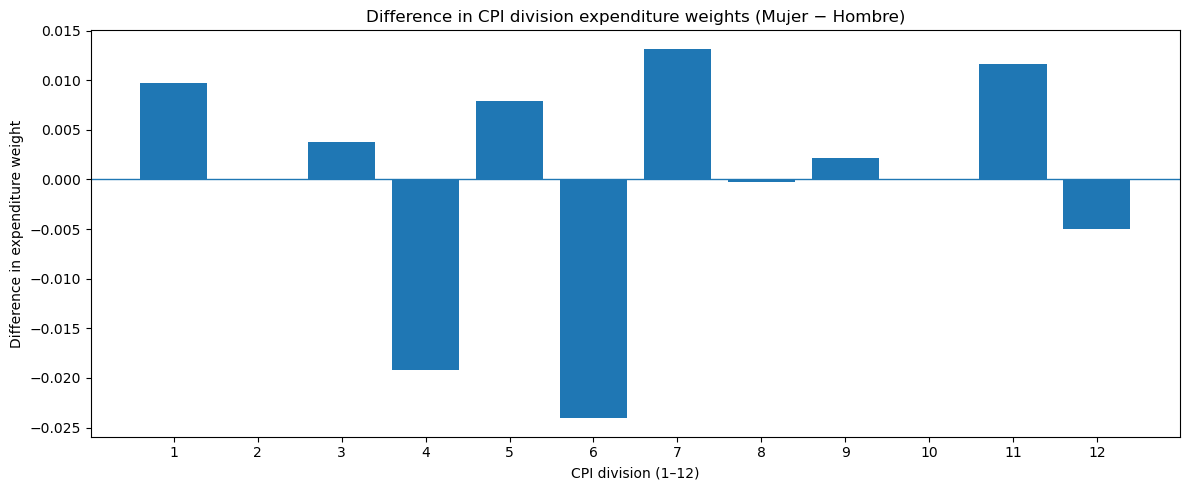

grupo,division_inpc,division_name,Hombre,Mujer,diff_M_minus_H
6,7.0,Transport,0.059202,0.072366,0.013164
10,11.0,Restaurants and hotels,0.095935,0.107560,0.011625
0,1.0,Food and non-alcoholic beverages,0.362402,0.372126,0.009723
4,5.0,"Furnishings, household equipment and routine m...",0.059048,0.066996,0.007948
2,3.0,Clothing and footwear,0.047477,0.051279,0.003802
8,9.0,Recreation and culture,0.045858,0.048017,0.002159
1,2.0,Alcoholic beverages and tobacco,0.000131,0.000199,0.000067
9,10.0,Education,0.020551,0.020597,0.000046
7,8.0,Communication,0.025719,0.025433,-0.000285
11,12.0,Miscellaneous goods and services,0.117733,0.112742,-0.004991


In [22]:
# Compute differences
wide["diff_M_minus_H"] = wide["Mujer"] - wide["Hombre"]

plt.figure(figsize=(12, 5))
plt.bar(wide["division_inpc"].astype(int).astype(str),
        wide["diff_M_minus_H"])
plt.axhline(0, linewidth=1)

plt.title("Difference in CPI division expenditure weights (Mujer − Hombre)")
plt.xlabel("CPI division (1–12)")
plt.ylabel("Difference in expenditure weight")
plt.tight_layout()
plt.show()

# Optional table: largest gaps
wide.sort_values("diff_M_minus_H", ascending=False)[
    ["division_inpc", "division_name", "Hombre", "Mujer", "diff_M_minus_H"]
]


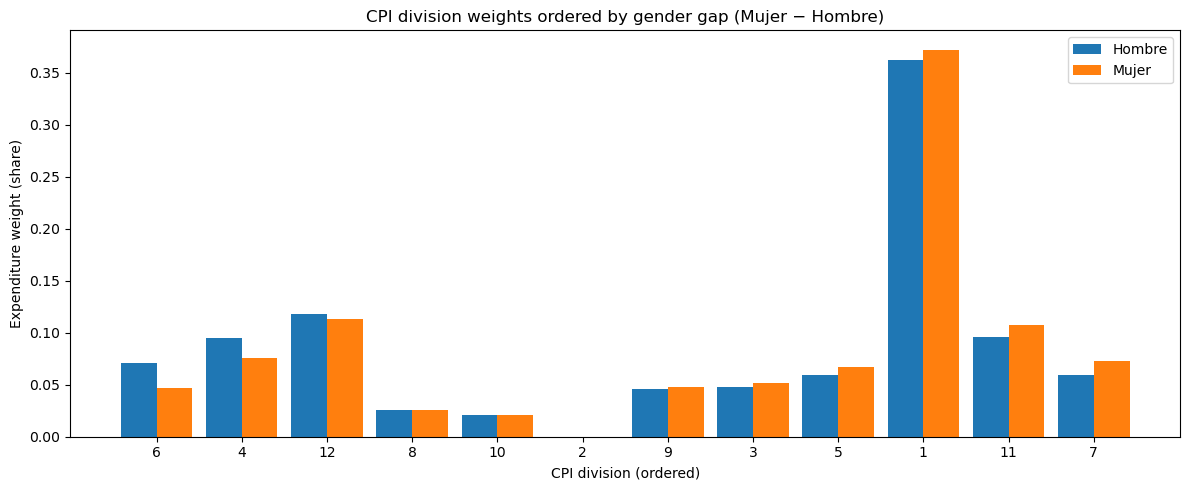

In [23]:
wide_gap = wide.sort_values("diff_M_minus_H")

x = np.arange(len(wide_gap))
bar_w = 0.42

plt.figure(figsize=(12, 5))
plt.bar(x - bar_w/2, wide_gap["Hombre"], width=bar_w, label="Hombre")
plt.bar(x + bar_w/2, wide_gap["Mujer"],  width=bar_w, label="Mujer")

plt.title("CPI division weights ordered by gender gap (Mujer − Hombre)")
plt.xlabel("CPI division (ordered)")
plt.ylabel("Expenditure weight (share)")
plt.xticks(x, wide_gap["division_inpc"].astype(int).astype(str))
plt.legend()
plt.tight_layout()
plt.show()


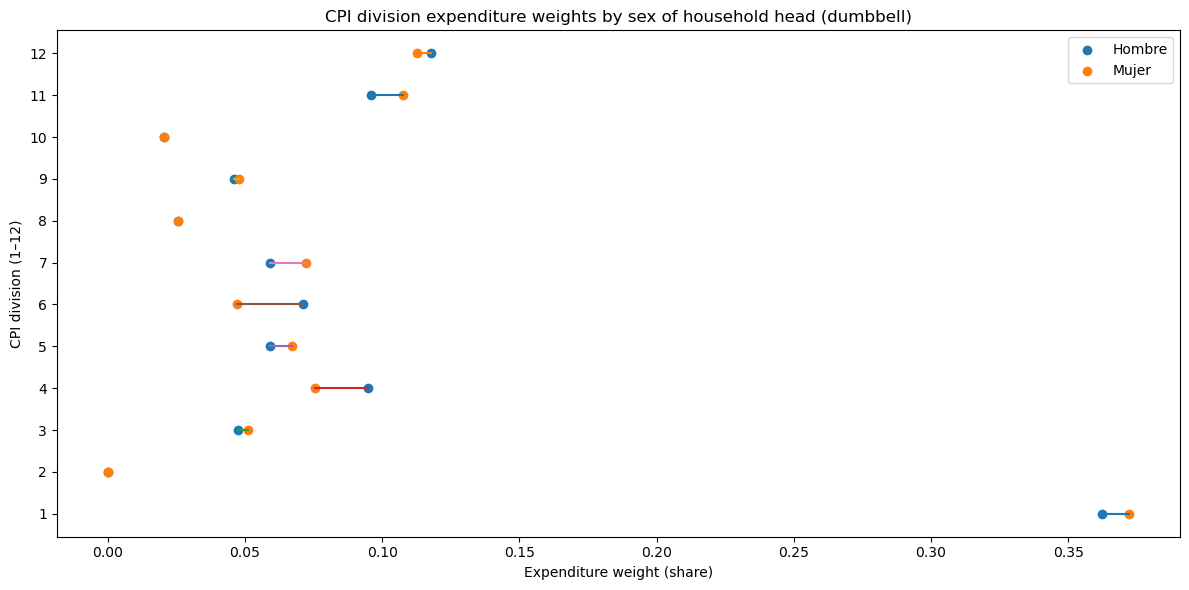

In [24]:
wide_plot = wide.sort_values("division_inpc").reset_index(drop=True)
y = np.arange(len(wide_plot))

plt.figure(figsize=(12, 6))

# Draw lines
for i in range(len(wide_plot)):
    plt.plot(
        [wide_plot.loc[i, "Hombre"], wide_plot.loc[i, "Mujer"]],
        [y[i], y[i]]
    )

# Draw points
plt.scatter(wide_plot["Hombre"], y, label="Hombre")
plt.scatter(wide_plot["Mujer"],  y, label="Mujer")

plt.yticks(y, wide_plot["division_inpc"].astype(int).astype(str))
plt.xlabel("Expenditure weight (share)")
plt.ylabel("CPI division (1–12)")
plt.title("CPI division expenditure weights by sex of household head (dumbbell)")
plt.legend()
plt.tight_layout()
plt.show()


The figures reveal systematic differences in expenditure composition between male- and female-headed households. Female-headed households allocate relatively higher shares to food, transport, and restaurants, while male-headed households place greater weight on housing, health, and household equipment. These differences are structural rather than price-driven and imply that inflationary shocks affecting specific CPI divisions may have heterogeneous impacts across household types. The results provide strong empirical motivation for constructing experimental, group-specific inflation measures.

CPI price changes by division (12 divisions)

In [25]:
import pandas as pd
from pathlib import Path

RAW = Path("ENIGH_e_2022")
OUT = RAW / "03_outputs"

# Load your division weights (Step 5 output)
pond_division = pd.read_csv(OUT / "ponderadores_division_por_grupo.csv")
pond_division["division_inpc"] = pond_division["division_inpc"].astype(int)

# Division catalog
div_catalog = (pond_division[["division_inpc", "division_name"]]
               .drop_duplicates()
               .sort_values("division_inpc")
               .reset_index(drop=True))

# Create an empty price-change table template
# You will fill: date, division_inpc, pi (inflation rate, e.g., 0.012 for 1.2%)
price_template = div_catalog.assign(dummy=1).drop(columns="dummy")

price_template["date"] = ""     # YYYY-MM
price_template["pi"] = None     # inflation rate as decimal
price_template = price_template[["date", "division_inpc", "division_name", "pi"]]

price_template.to_csv(OUT / "inpc_division_price_changes_TEMPLATE.csv", index=False)

price_template.head(24)


,date,division_inpc,division_name,pi
0,,1,Food and non-alcoholic beverages,None
1,,2,Alcoholic beverages and tobacco,None
2,,3,Clothing and footwear,None
3,,4,"Housing, water, electricity, gas and other fuels",None
4,,5,"Furnishings, household equipment and routine m...",None
5,,6,Health,None
6,,7,Transport,None
7,,8,Communication,None
8,,9,Recreation and culture,None
9,,10,Education,None


In [26]:
#Example: one month of CPI inflation (dummy values)
import pandas as pd
from pathlib import Path

RAW = Path("ENIGH_e_2022")
OUT = RAW / "03_outputs"

# Load the template you just created
price = pd.read_csv(OUT / "inpc_division_price_changes_TEMPLATE.csv")

# Fill ONE month with example inflation rates (replace later with real INPC data)
price["date"] = "2022-01"

example_pi = {
    1: 0.015,   # Food
    2: 0.010,   # Alcohol & tobacco
    3: 0.008,   # Clothing
    4: 0.006,   # Housing
    5: 0.007,   # Furnishings
    6: 0.005,   # Health
    7: 0.012,   # Transport
    8: 0.004,   # Communication
    9: 0.009,   # Recreation
    10: 0.003,  # Education
    11: 0.011,  # Restaurants
    12: 0.006   # Miscellaneous
}

price["pi"] = price["division_inpc"].map(example_pi)

price


,date,division_inpc,division_name,pi
0,2022-01,1,Food and non-alcoholic beverages,0.015
1,2022-01,2,Alcoholic beverages and tobacco,0.010
2,2022-01,3,Clothing and footwear,0.008
3,2022-01,4,"Housing, water, electricity, gas and other fuels",0.006
4,2022-01,5,"Furnishings, household equipment and routine m...",0.007
5,2022-01,6,Health,0.005
6,2022-01,7,Transport,0.012
7,2022-01,8,Communication,0.004
8,2022-01,9,Recreation and culture,0.009
9,2022-01,10,Education,0.003


As a proof of concept, division-level CPI price changes were introduced using a one-month example with plausible inflation rates. These values serve to validate the aggregation pipeline and isolate composition effects, ensuring that any observed inflation differences across household groups arise exclusively from expenditure weights rather than price variation

In [27]:
#Inflación experimental y brecha (con tus price dummy)
#Calcular inflacion por grupo

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

RAW = Path("ENIGH_e_2022")
OUT = RAW / "03_outputs"

pond_division = pd.read_csv(OUT / "ponderadores_division_por_grupo.csv")
pond_division["division_inpc"] = pond_division["division_inpc"].astype(int)

# Asegúrate de que 'price' existe (tu tabla de la imagen)
# Si no existe, descomenta:
# price = pd.read_csv(OUT / "inpc_division_price_changes_TEMPLATE.csv")

# Merge pesos + inflación por división
infl = pond_division.merge(
    price[["date", "division_inpc", "pi"]],
    on="division_inpc",
    how="left"
)

# QC: no deben quedar pi faltantes
missing = infl["pi"].isna().sum()
print("Missing pi after merge:", missing)

# Contribución por división
infl["contrib"] = infl["peso"] * infl["pi"]

# Inflación total por grupo
infl_group = (infl.groupby(["date", "grupo"], as_index=False)["contrib"]
                .sum()
                .rename(columns={"contrib": "inflation"}))

infl_group



Missing pi after merge: 0


,date,grupo,inflation
0,2022-01,Hombre,0.010204
1,2022-01,Mujer,0.010476


In [28]:
#BRECHA MUJER HOMBRE
gap = (infl_group.pivot(index="date", columns="grupo", values="inflation")
                 .reset_index())

gap["gap_M_minus_H"] = gap["Mujer"] - gap["Hombre"]
gap


grupo,date,Hombre,Mujer,gap_M_minus_H
0,2022-01,0.010204,0.010476,0.000271


In [29]:
#DESCOMPOSICION QYE DIVIIONES EXPLICAN LA BRECHA
# Tabla wide de pesos por división
w = (pond_division.pivot_table(index=["division_inpc","division_name"],
                               columns="grupo", values="peso")
                 .reset_index())

# Delta de pesos (M - H)
w["dw_M_minus_H"] = w["Mujer"] - w["Hombre"]

# Agrega pi (un mes)
pi = price[["division_inpc","pi"]].drop_duplicates()

decomp = w.merge(pi, on="division_inpc", how="left")

# Contribución a la brecha
decomp["gap_contrib"] = decomp["dw_M_minus_H"] * decomp["pi"]

# Ordena por impacto absoluto
decomp_sorted = decomp.sort_values("gap_contrib", ascending=False)

# QC: la suma de contribuciones debe igualar la brecha
print("Sum of gap contributions:", decomp["gap_contrib"].sum())
print("Gap (M-H) from totals:", float(gap["gap_M_minus_H"].iloc[0]))

decomp_sorted[["division_inpc","division_name","Hombre","Mujer","dw_M_minus_H","pi","gap_contrib"]]


Sum of gap contributions: 0.0002714133348315187
Gap (M-H) from totals: 0.0002714133348315183


,division_inpc,division_name,Hombre,Mujer,dw_M_minus_H,pi,gap_contrib
6,7,Transport,0.059202,0.072366,0.013164,0.012,1.579717e-04
0,1,Food and non-alcoholic beverages,0.362402,0.372126,0.009723,0.015,1.458453e-04
10,11,Restaurants and hotels,0.095935,0.107560,0.011625,0.011,1.278737e-04
4,5,"Furnishings, household equipment and routine m...",0.059048,0.066996,0.007948,0.007,5.563860e-05
2,3,Clothing and footwear,0.047477,0.051279,0.003802,0.008,3.041400e-05
8,9,Recreation and culture,0.045858,0.048017,0.002159,0.009,1.943034e-05
1,2,Alcoholic beverages and tobacco,0.000131,0.000199,0.000067,0.010,6.733456e-07
9,10,Education,0.020551,0.020597,0.000046,0.003,1.370279e-07
7,8,Communication,0.025719,0.025433,-0.000285,0.004,-1.140312e-06
11,12,Miscellaneous goods and services,0.117733,0.112742,-0.004991,0.006,-2.994883e-05


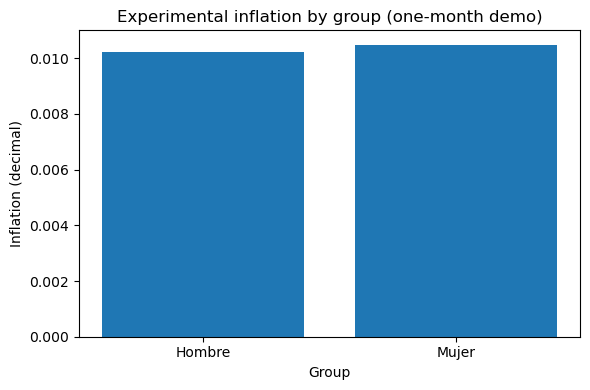

In [30]:
plt.figure(figsize=(6,4))
plt.bar(infl_group["grupo"], infl_group["inflation"])
plt.title("Experimental inflation by group (one-month demo)")
plt.xlabel("Group")
plt.ylabel("Inflation (decimal)")
plt.tight_layout()
plt.show()


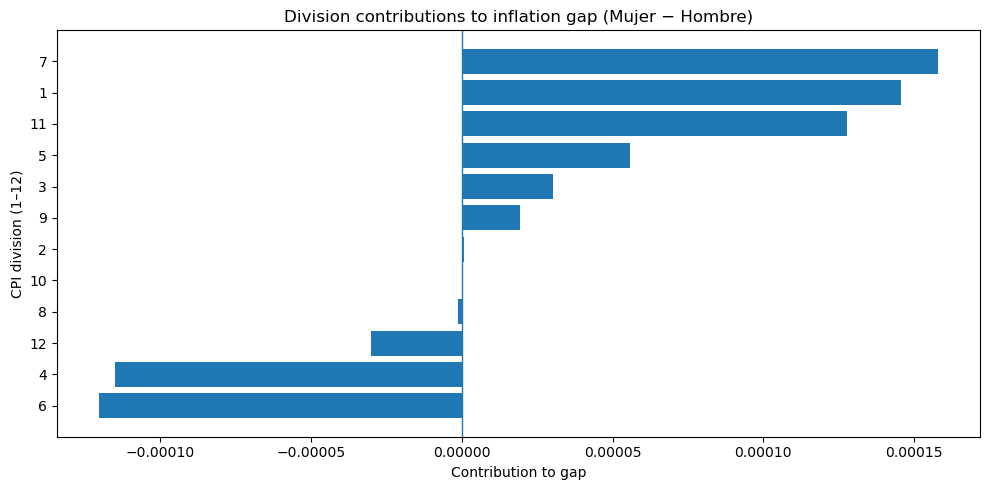

In [31]:
tmp = decomp.sort_values("gap_contrib")
plt.figure(figsize=(10,5))
plt.barh(tmp["division_inpc"].astype(int).astype(str), tmp["gap_contrib"])
plt.axvline(0, linewidth=1)
plt.title("Division contributions to inflation gap (Mujer − Hombre)")
plt.xlabel("Contribution to gap")
plt.ylabel("CPI division (1–12)")
plt.tight_layout()
plt.show()


In [37]:
from pathlib import Path

file_path = Path("INDICE 2022_2025.csv")
print(file_path.exists())



True


In [44]:
import pandas as pd
import numpy as np

# df_clean ya existe y tiene 'division_raw' (mes-año) + Índices... columnas

# 1) Definir el mapeo correcto 1–13 (CCIF mensual del BIE)
division_map = {
    "Índices":    (1,  "Food and non-alcoholic beverages"),
    "Índices.1":  (2,  "Alcoholic beverages, tobacco and narcotics"),
    "Índices.2":  (3,  "Clothing and footwear"),
    "Índices.3":  (4,  "Housing, water, electricity, gas and other fuels"),
    "Índices.4":  (5,  "Furnishings, household equipment and routine maintenance"),
    "Índices.5":  (6,  "Health"),
    "Índices.6":  (7,  "Transport"),
    "Índices.7":  (8,  "Information and communication"),
    "Índices.8":  (9,  "Recreation, sport and culture"),
    "Índices.9":  (10, "Education services"),
    "Índices.10": (11, "Restaurants and accommodation services"),
    "Índices.11": (12, "Insurance and financial services"),
    "Índices.12": (13, "Personal care, social protection and miscellaneous goods"),
}

# 2) Verificar qué columnas del mapa existen en tu df_clean
cols_present = [c for c in division_map.keys() if c in df_clean.columns]
print("Columns present:", cols_present)

# 3) Melt a formato largo
long = df_clean.melt(
    id_vars=["division_raw"],
    value_vars=cols_present,
    var_name="col",
    value_name="index"
)

# 4) Asignar division_inpc y nombre
long["division_inpc"] = long["col"].map(lambda x: division_map[x][0]).astype(int)
long["division_name"] = long["col"].map(lambda x: division_map[x][1])

# 5) Limpiar index a numérico
long["index"] = pd.to_numeric(long["index"], errors="coerce")

# 6) Parsear fecha: tus valores son tipo 'ene-22' (español)
meses = {"ene":"Jan","feb":"Feb","mar":"Mar","abr":"Apr","may":"May","jun":"Jun",
         "jul":"Jul","ago":"Aug","sep":"Sep","oct":"Oct","nov":"Nov","dic":"Dec"}

tmp = long["division_raw"].astype(str).str.strip().str.lower()
for es, en in meses.items():
    tmp = tmp.str.replace(es, en, regex=False)

long["date"] = pd.to_datetime(tmp, format="%b-%y", errors="coerce")
long["date"] = long["date"].dt.to_period("M").astype(str)

# 7) Quitar basura
long = long.dropna(subset=["date", "index"]).sort_values(["date","division_inpc"]).reset_index(drop=True)

long.head(20), long.shape


Columns present: ['Índices', 'Índices.1', 'Índices.2', 'Índices.3', 'Índices.4', 'Índices.5', 'Índices.6', 'Índices.7', 'Índices.8', 'Índices.9', 'Índices.10', 'Índices.11', 'Índices.12']


(   division_raw         col       index  division_inpc  \
 0        ene-22     Índices  118.002000              1   
 1        ene-22   Índices.1  127.499764              2   
 2        ene-22   Índices.2  122.669375              3   
 3        ene-22   Índices.3  110.206714              4   
 4        ene-22   Índices.4  114.152749              5   
 5        ene-22   Índices.5  118.234758              6   
 6        ene-22   Índices.6  116.030614              7   
 7        ene-22   Índices.7  113.815554              8   
 8        ene-22   Índices.8  100.385786              9   
 9        ene-22   Índices.9  113.527184             10   
 10       ene-22  Índices.10  113.603608             11   
 11       ene-22  Índices.11  121.195352             12   
 12       ene-22  Índices.12  119.867734             13   
 13       feb-22     Índices  118.981000              1   
 14       feb-22   Índices.1  128.548248              2   
 15       feb-22   Índices.2  123.143842              3 

In this block, I compute monthly inflation rates for each CPI division using the official INPC CCIF index series. Inflation is defined as the month-to-month percentage change in the index within each division. These division-level inflation rates (pi) will later be combined with ENIGH expenditure weights to estimate group-specific inflation.

In [45]:
# Ensure correct order
long = long.sort_values(["division_inpc", "date"]).copy()

# Monthly inflation rate by division
long["pi"] = long.groupby("division_inpc")["index"].pct_change()

# Quick check: non-missing pi counts by division
long.groupby("division_inpc")["pi"].apply(lambda s: s.notna().sum()).head()


division_inpc
1    47
2    47
3    47
4    47
5    47
Name: pi, dtype: int64

Loading ENIGH expenditure weights by group


In this step, ENIGH-based expenditure weights by CPI division and by sex of household head are loaded. These weights represent the relative importance of each consumption division in household expenditure and are the key component that differentiates inflation experiences across groups. At this stage, the weights are still defined for a 12-division structure and will be harmonized with the 13-division CCIF classification in subsequent steps.

In [46]:
from pathlib import Path
import pandas as pd

RAW = Path("ENIGH_e_2022")
OUT = RAW / "03_outputs"

# Load ENIGH division-level weights (12 divisions)
pond_div = pd.read_csv(OUT / "ponderadores_division_por_grupo.csv")

pond_div.head(), pond_div["division_inpc"].unique()


(    grupo  division_inpc                                      division_name  \
 0  Hombre            1.0                   Food and non-alcoholic beverages   
 1  Hombre            2.0                    Alcoholic beverages and tobacco   
 2  Hombre            3.0                              Clothing and footwear   
 3  Hombre            4.0   Housing, water, electricity, gas and other fuels   
 4  Hombre            5.0  Furnishings, household equipment and routine m...   
 
        peso  
 0  0.362402  
 1  0.000131  
 2  0.047477  
 3  0.094685  
 4  0.059048  ,
 array([ 1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12.]))

In this step, I derive a transparent rule to expand the ENIGH weights from 12 to 13 divisions to match the CCIF structure of the INPC. Because the ENIGH weights currently include a single “miscellaneous” division (12), I compute relative shares for divisions 12 and 13 using official INPC information. These shares will be used to split the original ENIGH weight for division 12 into two components that are consistent with CCIF divisions 12 and 13.This step derives a transparent and reproducible rule to expand the ENIGH expenditure weights from 12 to 13 CCIF divisions. Using official INPC CCIF data, I compute the average index level for divisions 12 (Insurance and financial services) and 13 (Personal care, social protection and miscellaneous goods). These averages are used to construct proportional shares that sum to one, allowing the original ENIGH “miscellaneous” weight to be split consistently across the two CCIF categories.

In [47]:
# Use the official INPC CCIF series to compute split shares for divisions 12 and 13
avg_index = (long[long["division_inpc"].isin([12, 13])]
             .groupby("division_inpc")["index"]
             .mean())

share12 = avg_index.loc[12] / (avg_index.loc[12] + avg_index.loc[13])
share13 = avg_index.loc[13] / (avg_index.loc[12] + avg_index.loc[13])

print("Average index levels:")
print(avg_index)

print("\nSplit shares:")
print("share12 (division 12) =", float(share12))
print("share13 (division 13) =", float(share13))
print("sum =", float(share12 + share13))


Average index levels:
division_inpc
12    144.74196
13    151.91482
Name: index, dtype: float64

Split shares:
share12 (division 12) = 0.48791050635760846
share13 (division 13) = 0.5120894936423916
sum = 1.0


In this step, ENIGH division-level expenditure weights are harmonized with the 13-division CCIF structure of the INPC. Divisions 1 to 11 remain unchanged, while the original ENIGH division 12 is split into two components corresponding to CCIF divisions 12 and 13 using the shares derived from official INPC data. A quality control check is performed to ensure that the expanded weights continue to sum to one within each household group

In [48]:
# Keep divisions 1–11 unchanged
base_1_11 = pond_div[pond_div["division_inpc"].between(1, 11)].copy()

# Extract original ENIGH division 12
old12 = pond_div[pond_div["division_inpc"] == 12].copy()

# Create new division 12 (Insurance and financial services)
new12 = old12.copy()
new12["division_inpc"] = 12
new12["division_name"] = "Insurance and financial services"
new12["peso"] = new12["peso"] * share12

# Create new division 13 (Personal care, social protection and miscellaneous goods)
new13 = old12.copy()
new13["division_inpc"] = 13
new13["division_name"] = "Personal care, social protection and miscellaneous goods"
new13["peso"] = new13["peso"] * share13

# Combine into 13-division weight table
pond_div_13 = pd.concat([base_1_11, new12, new13], ignore_index=True)

# Quality control: weights must sum to 1 by group
qc_weights = pond_div_13.groupby("grupo")["peso"].sum()
print("QC — sum of weights by group:")
print(qc_weights)

pond_div_13.sort_values(["grupo", "division_inpc"]).head(30)


QC — sum of weights by group:
grupo
Hombre    1.0
Mujer     1.0
Name: peso, dtype: float64


,grupo,division_inpc,division_name,peso
0,Hombre,1.0,Food and non-alcoholic beverages,0.362402
1,Hombre,2.0,Alcoholic beverages and tobacco,0.000131
2,Hombre,3.0,Clothing and footwear,0.047477
3,Hombre,4.0,"Housing, water, electricity, gas and other fuels",0.094685
4,Hombre,5.0,"Furnishings, household equipment and routine m...",0.059048
5,Hombre,6.0,Health,0.071259
6,Hombre,7.0,Transport,0.059202
7,Hombre,8.0,Communication,0.025719
8,Hombre,9.0,Recreation and culture,0.045858
9,Hombre,10.0,Education,0.020551


This step expands the ENIGH-based expenditure weights to align with the 13-division CCIF classification used by the INPC. Divisions 1 to 11 remain unchanged, while the original ENIGH “miscellaneous” division is split into CCIF divisions 12 (Insurance and financial services) and 13 (Personal care, social protection and miscellaneous goods) using shares derived from official INPC data. A quality control check confirms that the expanded weights sum to one within each household group, ensuring internal consistency

In [49]:
pond13_path = OUT / "ponderadores_division13_por_grupo.csv"
pond_div_13.to_csv(pond13_path, index=False)
print("Saved:", pond13_path)


Saved: ENIGH_e_2022\03_outputs\ponderadores_division13_por_grupo.csv


In this step, the harmonized 13-division ENIGH expenditure weights are saved as the final weight input for the computation of group-specific inflation rates. These weights will be merged with division-level CPI inflation to estimate monthly inflation paths for male- and female-headed households.

In [50]:
panel = (
    pond_div_13
    .merge(long[["date", "division_inpc", "pi"]], on="division_inpc", how="left")
)

panel["contrib"] = panel["peso"] * panel["pi"]

panel.head()


,grupo,division_inpc,division_name,peso,date,pi,contrib
0,Hombre,1.0,Food and non-alcoholic beverages,0.362402,2022-01,NaN,NaN
1,Hombre,1.0,Food and non-alcoholic beverages,0.362402,2022-02,0.008296,0.003007
2,Hombre,1.0,Food and non-alcoholic beverages,0.362402,2022-03,0.009901,0.003588
3,Hombre,1.0,Food and non-alcoholic beverages,0.362402,2022-04,0.005409,0.001960
4,Hombre,1.0,Food and non-alcoholic beverages,0.362402,2022-05,0.001763,0.000639


This step above combines the harmonized ENIGH expenditure weights with division-level CPI inflation rates. By multiplying weights and price changes, division-specific inflation contributions are obtained for each household group. This step merges the harmonized ENIGH expenditure weights with division-level CPI inflation rates. For each household group and CPI division, inflation contributions are computed as the product of the expenditure weight and the monthly price change. The resulting panel contains the building blocks needed to aggregate inflation across divisions.

In this step, monthly inflation rates are computed separately for male- and female-headed households by summing division-level inflation contributions. Because the same CPI price changes apply to all households, differences in inflation across groups reflect only differences in expenditure composition.

In [51]:
infl_group = (
    panel
    .groupby(["date", "grupo"], as_index=False)["contrib"]
    .sum()
    .rename(columns={"contrib": "inflation"})
)

infl_group.head(12)


,date,grupo,inflation
0,2022-01,Hombre,0.000000
1,2022-01,Mujer,0.000000
2,2022-02,Hombre,0.008632
3,2022-02,Mujer,0.008436
4,2022-03,Hombre,0.007277
5,2022-03,Mujer,0.007201
6,2022-04,Hombre,0.004155
7,2022-04,Mujer,0.003900
8,2022-05,Hombre,0.001117
9,2022-05,Mujer,0.000948


his output reports the estimated monthly inflation rate for each household group by summing CPI-division contributions (weight × division inflation). The resulting time series provides one inflation observation per month for male- and female-headed households. Differences between groups are driven entirely by expenditure composition, since the same official CPI price changes are applied to both groups.

In [52]:
# Pivot to wide format for easy gap computation
wide_infl = infl_group.pivot(index="date", columns="grupo", values="inflation").reset_index()

# Optional: set first month to NaN if it came from "all-NaN contributions"
# (Detect months where all pi were NaN before aggregation)
# If you want a simpler rule: set the very first date to NaN.
first_date = wide_infl["date"].min()
wide_infl.loc[wide_infl["date"] == first_date, ["Hombre", "Mujer"]] = pd.NA

# Gap: Mujer - Hombre
wide_infl["gap_mujer_menos_hombre"] = wide_infl["Mujer"] - wide_infl["Hombre"]

wide_infl.head(12)


grupo,date,Hombre,Mujer,gap_mujer_menos_hombre
0,2022-01,NaN,NaN,NaN
1,2022-02,0.008632,0.008436,-0.000195
2,2022-03,0.007277,0.007201,-0.000076
3,2022-04,0.004155,0.003900,-0.000255
4,2022-05,0.001117,0.000948,-0.000169
5,2022-06,0.006737,0.006491,-0.000246
6,2022-07,0.005013,0.005163,0.000150
7,2022-08,0.006877,0.006713,-0.000163
8,2022-09,0.006725,0.006628,-0.000096
9,2022-10,0.005393,0.005227,-0.000166


This table reports estimated monthly inflation rates for male- and female-headed households and the resulting inflation gap, defined as the difference between female and male inflation rates. The first month is set to missing values because inflation cannot be computed without a prior period. From February 2022 onward, the results show small but systematic differences in inflation across groups. Negative values of the gap indicate months in which male-headed households experienced slightly higher inflation, while positive values indicate higher inflation for female-headed households. These differences arise exclusively from variations in expenditure composition across groups.

In this step, the inflation gap is decomposed into division-level contributions. For each month, the contribution of a CPI division is computed as the product of the difference in expenditure weights between groups and the division-specific inflation rate. This decomposition allows identification of the consumption categories that drive differences in inflation experiences across households

In [53]:
# Compute weight differences (Mujer - Hombre)
w_wide = (
    pond_div_13
    .pivot(index="division_inpc", columns="grupo", values="peso")
    .reset_index()
)

w_wide["dw_mujer_menos_hombre"] = w_wide["Mujer"] - w_wide["Hombre"]

# Merge with division inflation
decomp = (
    long[["date", "division_inpc", "pi"]]
    .merge(w_wide[["division_inpc", "dw_mujer_menos_hombre"]], on="division_inpc", how="left")
)

# Contribution to the gap
decomp["gap_contrib"] = decomp["dw_mujer_menos_hombre"] * decomp["pi"]

decomp.head(12)


,date,division_inpc,pi,dw_mujer_menos_hombre,gap_contrib
0,2022-01,1,NaN,0.009723,NaN
1,2022-02,1,0.008296,0.009723,0.000081
2,2022-03,1,0.009901,0.009723,0.000096
3,2022-04,1,0.005409,0.009723,0.000053
4,2022-05,1,0.001763,0.009723,0.000017
5,2022-06,1,0.008445,0.009723,0.000082
6,2022-07,1,0.007407,0.009723,0.000072
7,2022-08,1,0.006954,0.009723,0.000068
8,2022-09,1,0.006203,0.009723,0.000060
9,2022-10,1,0.005659,0.009723,0.000055


This step decomposes the monthly inflation gap (Mujer − Hombre) into CPI-division contributions. For each division, we compute the difference in expenditure weights between groups and multiply it by the division’s official monthly inflation rate. The resulting gap_contrib measures how much each consumption division contributes to the overall inflation gap in each month, allowing us to identify which categories systematically drive differences in inflation experiences.

In [54]:
# Sum contributions by month
gap_from_decomp = (
    decomp.groupby("date", as_index=False)["gap_contrib"]
    .sum()
    .rename(columns={"gap_contrib": "gap_from_decomp"})
)

# Compare with the gap we computed earlier
check = wide_infl.merge(gap_from_decomp, on="date", how="left")

check["diff"] = check["gap_mujer_menos_hombre"] - check["gap_from_decomp"]

check.head(12)


,date,Hombre,Mujer,gap_mujer_menos_hombre,gap_from_decomp,diff
0,2022-01,NaN,NaN,NaN,0.000000,NaN
1,2022-02,0.008632,0.008436,-0.000195,-0.000195,-1.897354e-18
2,2022-03,0.007277,0.007201,-0.000076,-0.000076,2.574980e-19
3,2022-04,0.004155,0.003900,-0.000255,-0.000255,0.000000e+00
4,2022-05,0.001117,0.000948,-0.000169,-0.000169,5.421011e-20
5,2022-06,0.006737,0.006491,-0.000246,-0.000246,-3.794708e-19
6,2022-07,0.005013,0.005163,0.000150,0.000150,7.860466e-19
7,2022-08,0.006877,0.006713,-0.000163,-0.000163,-3.523657e-19
8,2022-09,0.006725,0.006628,-0.000096,-0.000096,-6.776264e-20
9,2022-10,0.005393,0.005227,-0.000166,-0.000166,-2.710505e-19


In [55]:
avg_contrib = (
    decomp.dropna(subset=["pi"])
    .groupby("division_inpc", as_index=False)["gap_contrib"]
    .mean()
    .sort_values("gap_contrib", ascending=False)
)

avg_contrib.head(13)


,division_inpc,gap_contrib
6,7,5.757145e-05
10,11,5.380404e-05
0,1,3.993086e-05
4,5,1.832293e-05
2,3,1.680797e-05
1,2,3.512294e-07
9,10,1.971854e-07
7,8,-1.007862e-06
8,9,-4.083819e-06
11,12,-1.623373e-05


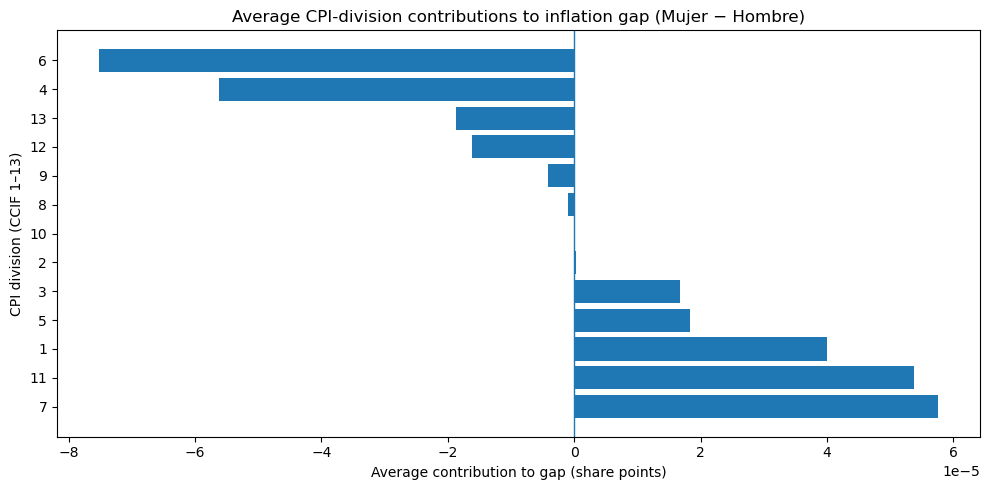

In [56]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.axvline(0, linewidth=1)

plt.barh(
    avg_contrib["division_inpc"].astype(int).astype(str),
    avg_contrib["gap_contrib"]
)

plt.title("Average CPI-division contributions to inflation gap (Mujer − Hombre)")
plt.xlabel("Average contribution to gap (share points)")
plt.ylabel("CPI division (CCIF 1–13)")
plt.tight_layout()
plt.show()


In [57]:
month = "2022-02"

top_month = (
    decomp[decomp["date"] == month]
    .dropna(subset=["pi"])
    .sort_values("gap_contrib", ascending=False)
)

display(top_month.head(6))
display(top_month.tail(6))


,date,division_inpc,pi,dw_mujer_menos_hombre,gap_contrib
289,2022-02,7,0.009258,0.013164,1.218780e-04
1,2022-02,1,0.008296,0.009723,8.066672e-05
193,2022-02,5,0.008816,0.007948,7.007104e-05
481,2022-02,11,0.004913,0.011625,5.710906e-05
97,2022-02,3,0.003868,0.003802,1.470459e-05
49,2022-02,2,0.008223,0.000067,5.537203e-07


,date,division_inpc,pi,dw_mujer_menos_hombre,gap_contrib
337,2022-02,8,0.009311,-0.000285,-0.000003
385,2022-02,9,-0.001230,0.002159,-0.000003
529,2022-02,12,0.010921,-0.002435,-0.000027
577,2022-02,13,0.019809,-0.002556,-0.000051
145,2022-02,4,0.009916,-0.019193,-0.000190
241,2022-02,6,0.011124,-0.024065,-0.000268
